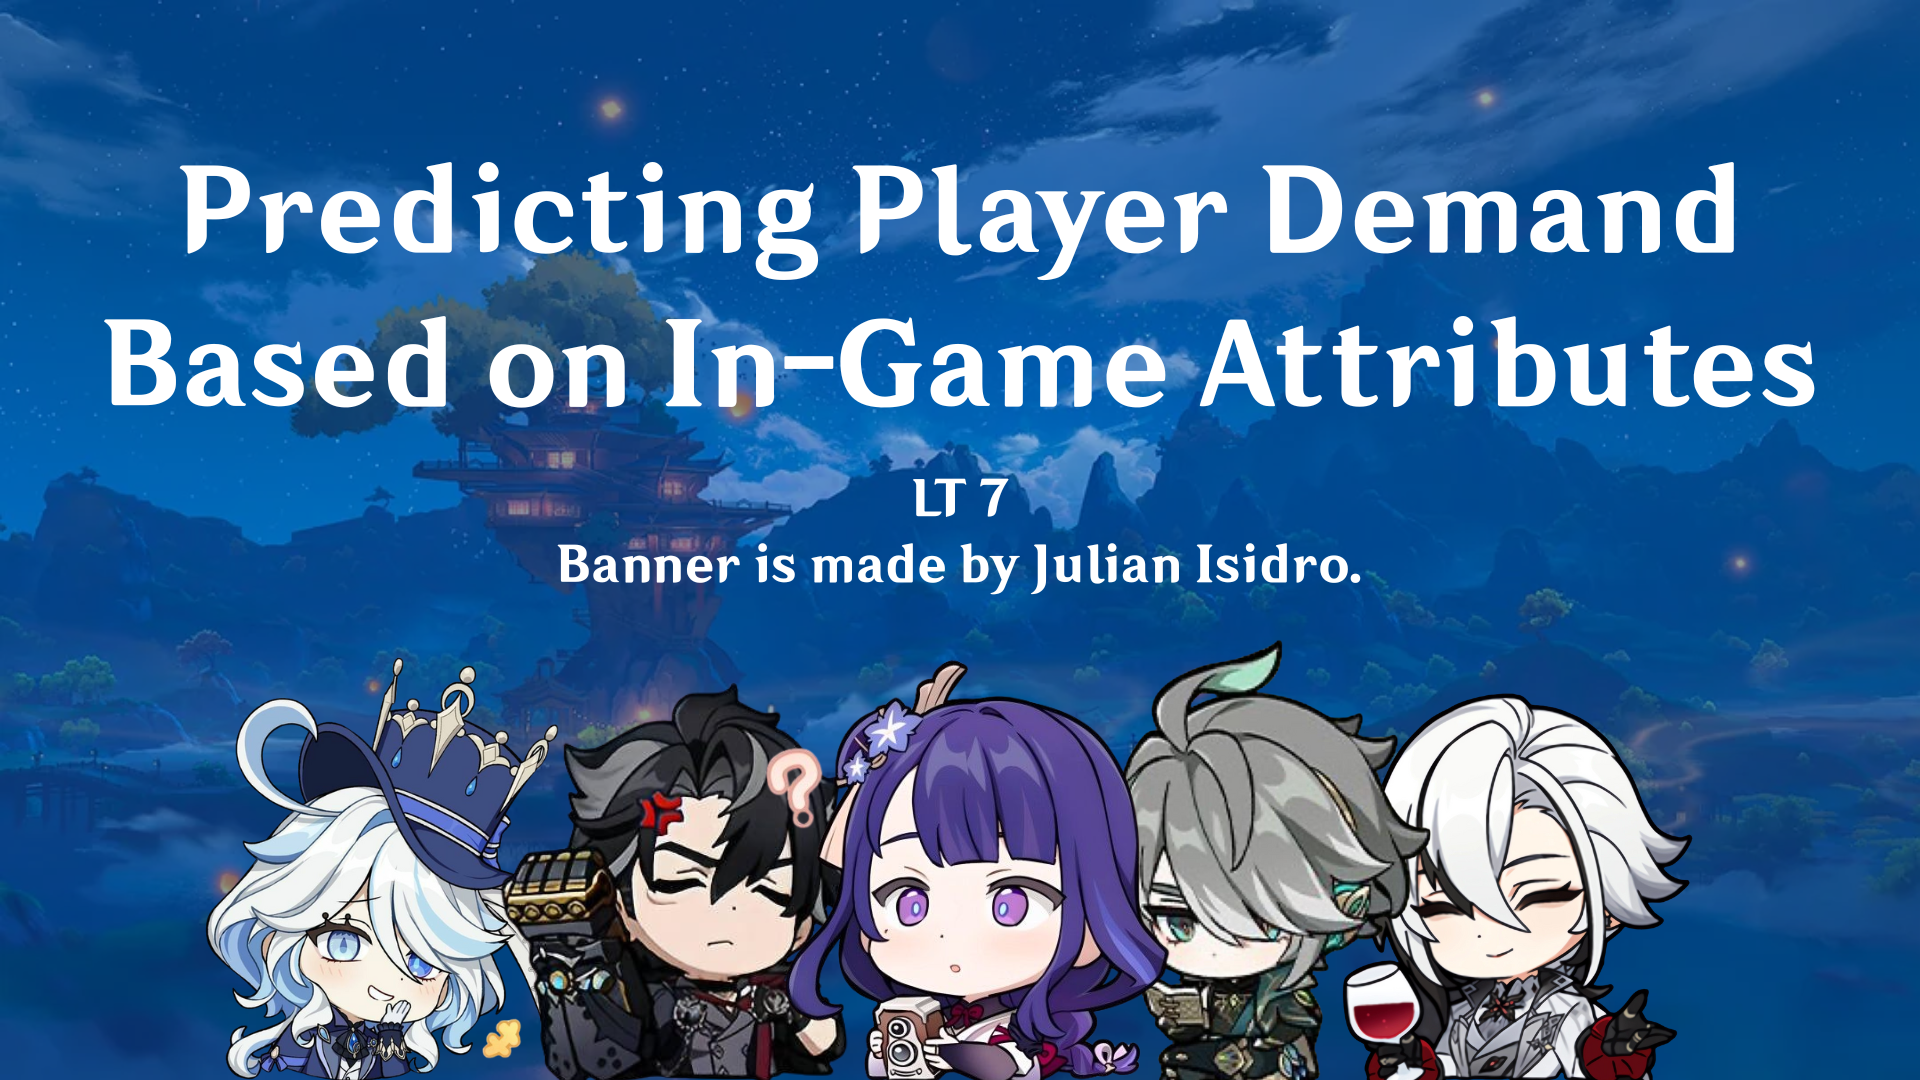

In [1]:
!pip install -q lxml

In [2]:
import os
import pickle
import re

import centrality_maker
import characteristics_maker
import graph_maker
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

# I. Executive Summary

# II. Introduction

Genshin Impact is a popular video game where players control different characters to fight enemies, complete quests, and explore a large open world. As players progress, they look for ways to make their characters stronger so they can handle harder challenges in the game. One of the main ways to strengthen a character is by getting new ones or upgrading existing ones through a system called “pulling.”

Pulling works like a lottery or opening a pack of random cards. Players spend in-game currency and hope to receive the character they want. Some characters are easy to get, while others are rare. The rare ones are called “five-star” characters, and the more common ones are called “four-star” characters. In addition, if a player already owns a character, they can unlock “constellations,” which are extra upgrades that make the character even stronger. To unlock a constellation, players must pull the same character again. Because of this, counting how many times a character is pulled helps us understand how popular or desirable that character is.

In gacha games like Genshin Impact, players who really want a specific character may even spend real money to increase their chances of getting them. For this reason, we use the number of times a character was pulled as a way to measure player demand. This is especially useful for rare five-star characters, since obtaining them often takes many pulls. Figure 1 is an accurate representation of JF when he will start pulling for Varka soon. The stronger the demand (usually means) the more the number of pulls.

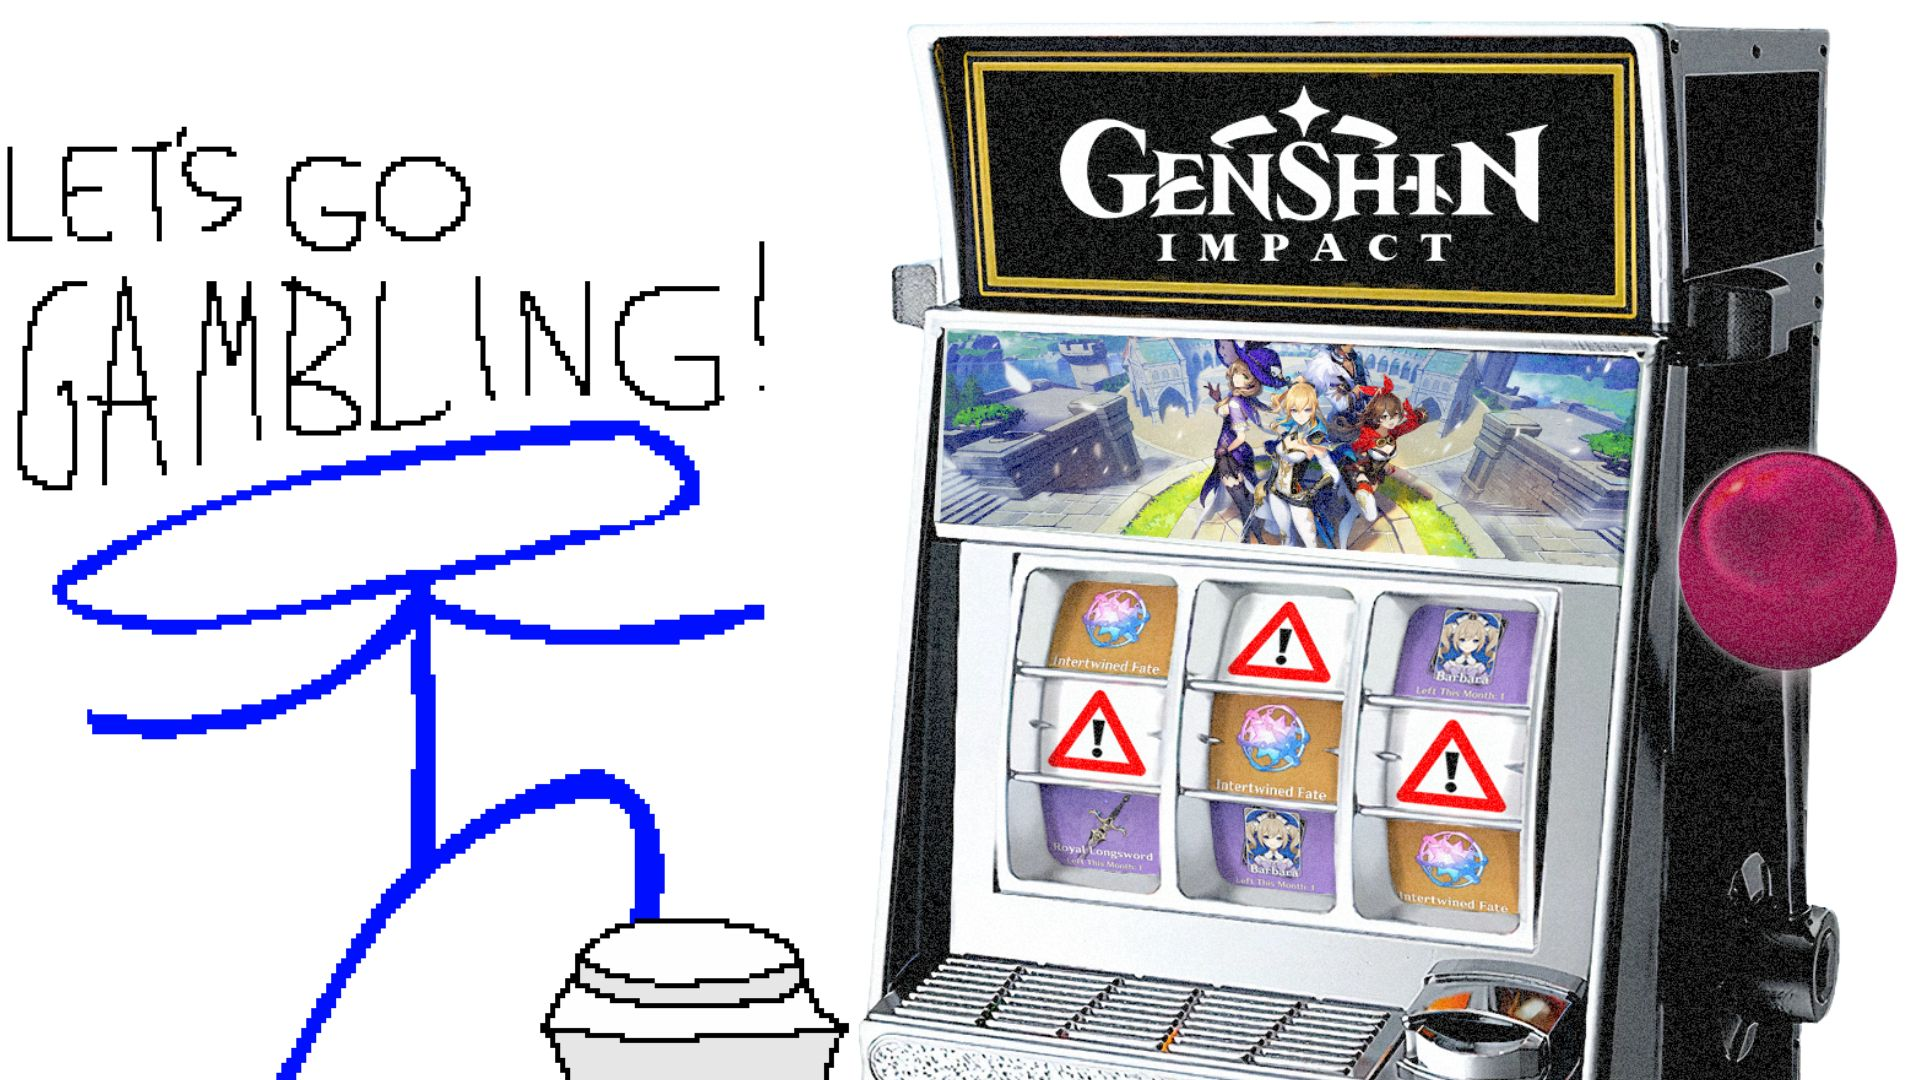
**Figure 1.** Player Demand in Action: Pulling for Popular Characters

Thus, the objective of the study is to determine how does the characteristics of a character affect player demand for them. We ask these following questions that will guide us for the webscraping and exploratory data analysis:
1. Does a character’s strength or usefulness increase player interest?
    - How does a character’s combat role (damage dealer, support, or survivability-oriented) influence player interest in pulling for them?
    - Are stronger or more commonly used characters pulled more often? How would we even try to measure character strength?
2. Are characters who appear frequently or play major roles in the storyline pulled more?
3. Are certain character demographics like gender and body type more appealing to players?
    - Since Genshin Impact is a gacha game with a large male player base, do female characters receive more pulls?


# III. Methodology Overview

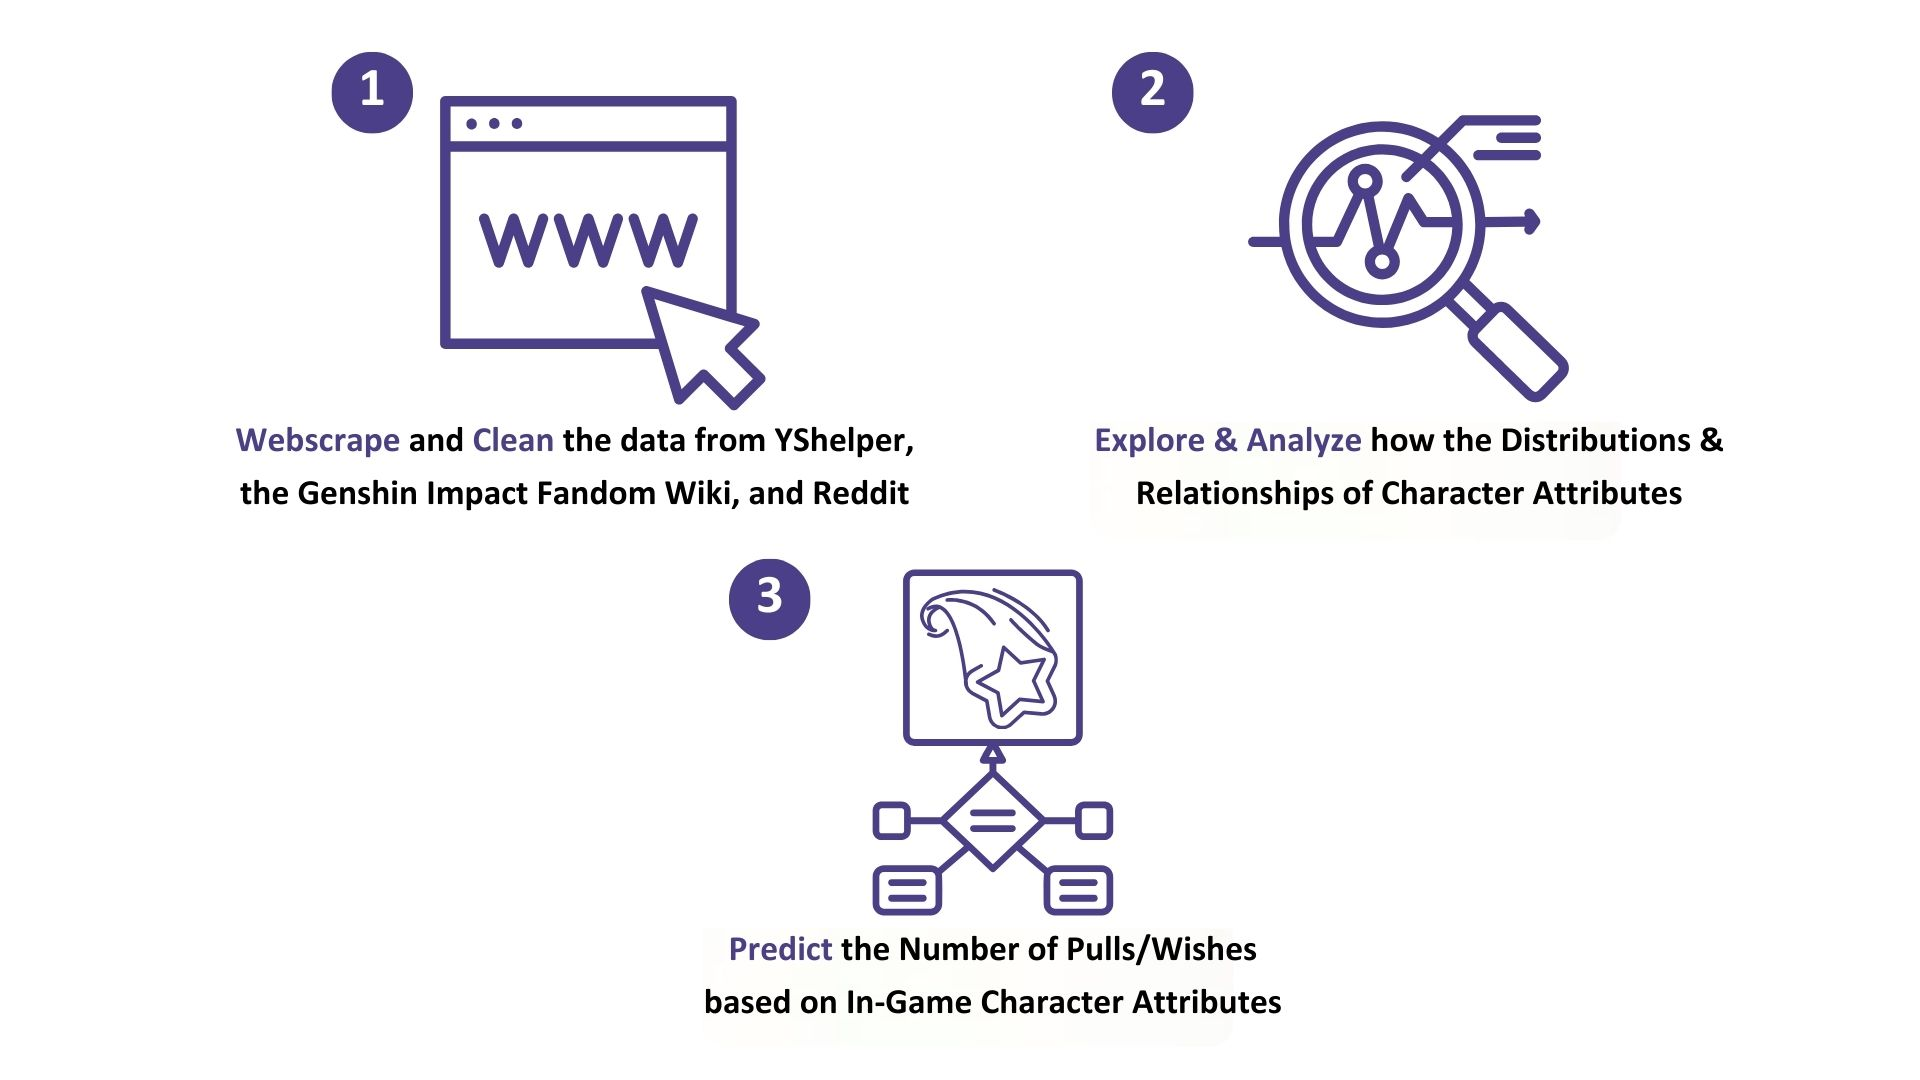
**Figure 2.** Methodology Overview

*3.1 Webscrape and Clean the data from YShelper, the Genshin Impact Fandom Wiki, and Reddit*

We gathered team compositions from YSHelper, Reddit, and the Genshin Fandom Wiki, then cleaned and standardized all character information. This gave us a consistent dataset linking characters, their teams, and their usage patterns.

*3.2 Explore & Analyze how the Distributions & Relationships of Character Attributes*

We examined the distributions of character stats and attributes to understand how they vary across the roster. We also analyzed how these attributes relate to each other, such as correlations between roles, elements, and base stats.

*3.3 Predict the Number of Pulls/Wishes  based on In-Game Character Attributes*

We built models using character attributes to predict the number of pulls a character receives. For this analysis, we focus only on the current ownership, ignoring variations from previous months. We started with simpler models like Random Forests and later experimented with more complex approaches, such as neural networks.


# IV. Webscrape and Clean the data from YShelper and the Genshin Impact Fandom Wiki, and Reddit

In Genshin Impact, the endgame enemy lineup changes roughly every month, so character usage naturally shifts as players adjust their teams to counter new enemies. For this study, we focus only on the latest enemy lineup and the most recent ownership data, meaning earlier monthly variations are not considered. Although we were able to web scrape past data, time constraints led us to concentrate on predicting the latest available character ownerships.
The `characteristics_maker` module includes several functions. One of its main functions identifies all playable characters and gathers two monthly values:
How many players own each character, and
How many players actually use them in endgame content.

Figure 3 shows an example of these ownership and usage counts. The module also lets us view more details about each character, such as the distribution of their constellations (upgrade levels).

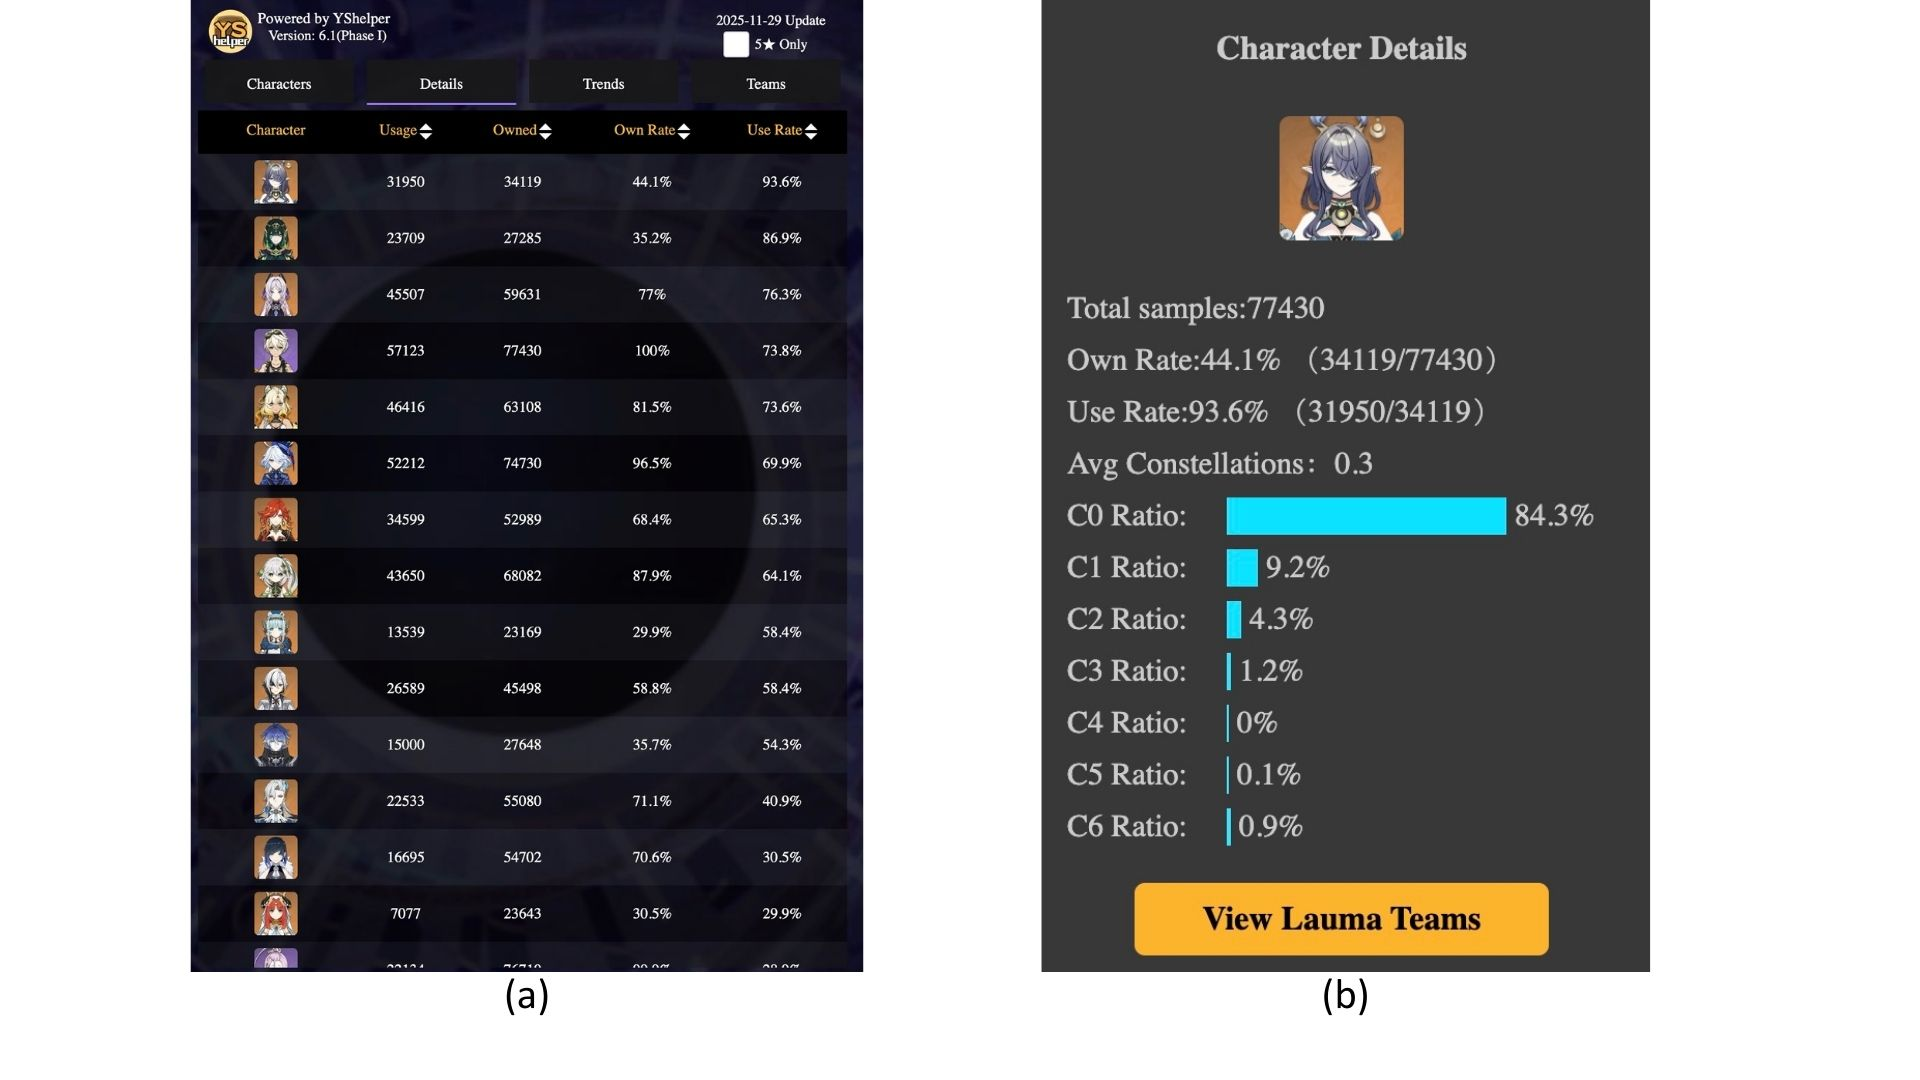


**Figure 3.** YSHelper Character Data Interface with (a) overview of all playable characters showing monthly ownership and usage counts and (b) detailed view for a specific character, including constellation distribution

In [3]:
df_ownership = characteristics_maker.get_character_ownership()
df_ownership.head()

,Name,Star,Use,Own,Pull Number
0,Lauma,5,31950,34119,43433
1,Nefer,5,23709,27285,38035
2,Citlali,5,45507,59631,90042
3,Bennett,4,57123,77430,497023
4,Xilonen,5,46416,63108,85637


We also collect team-level data for two end-game modes, Spiral Abyss and Stygian Onslaught. Another function in the `graph_maker` module retrieves popular team compositions (“team comps”) from YSHelper. For each month, YSHelper provides how often each team was used and owned. Using this team data, the module calculates how often pairs of characters appear together in actual usage. For example, in Figure 3b, the total appearances for the shown team amount to 18,842. We represent these relationships using a character co-usage graph built with `NetworkX`. In this graph, each node represents a character, and each edge shows how frequently two characters are used together, with the edge weight indicating total co-usage.


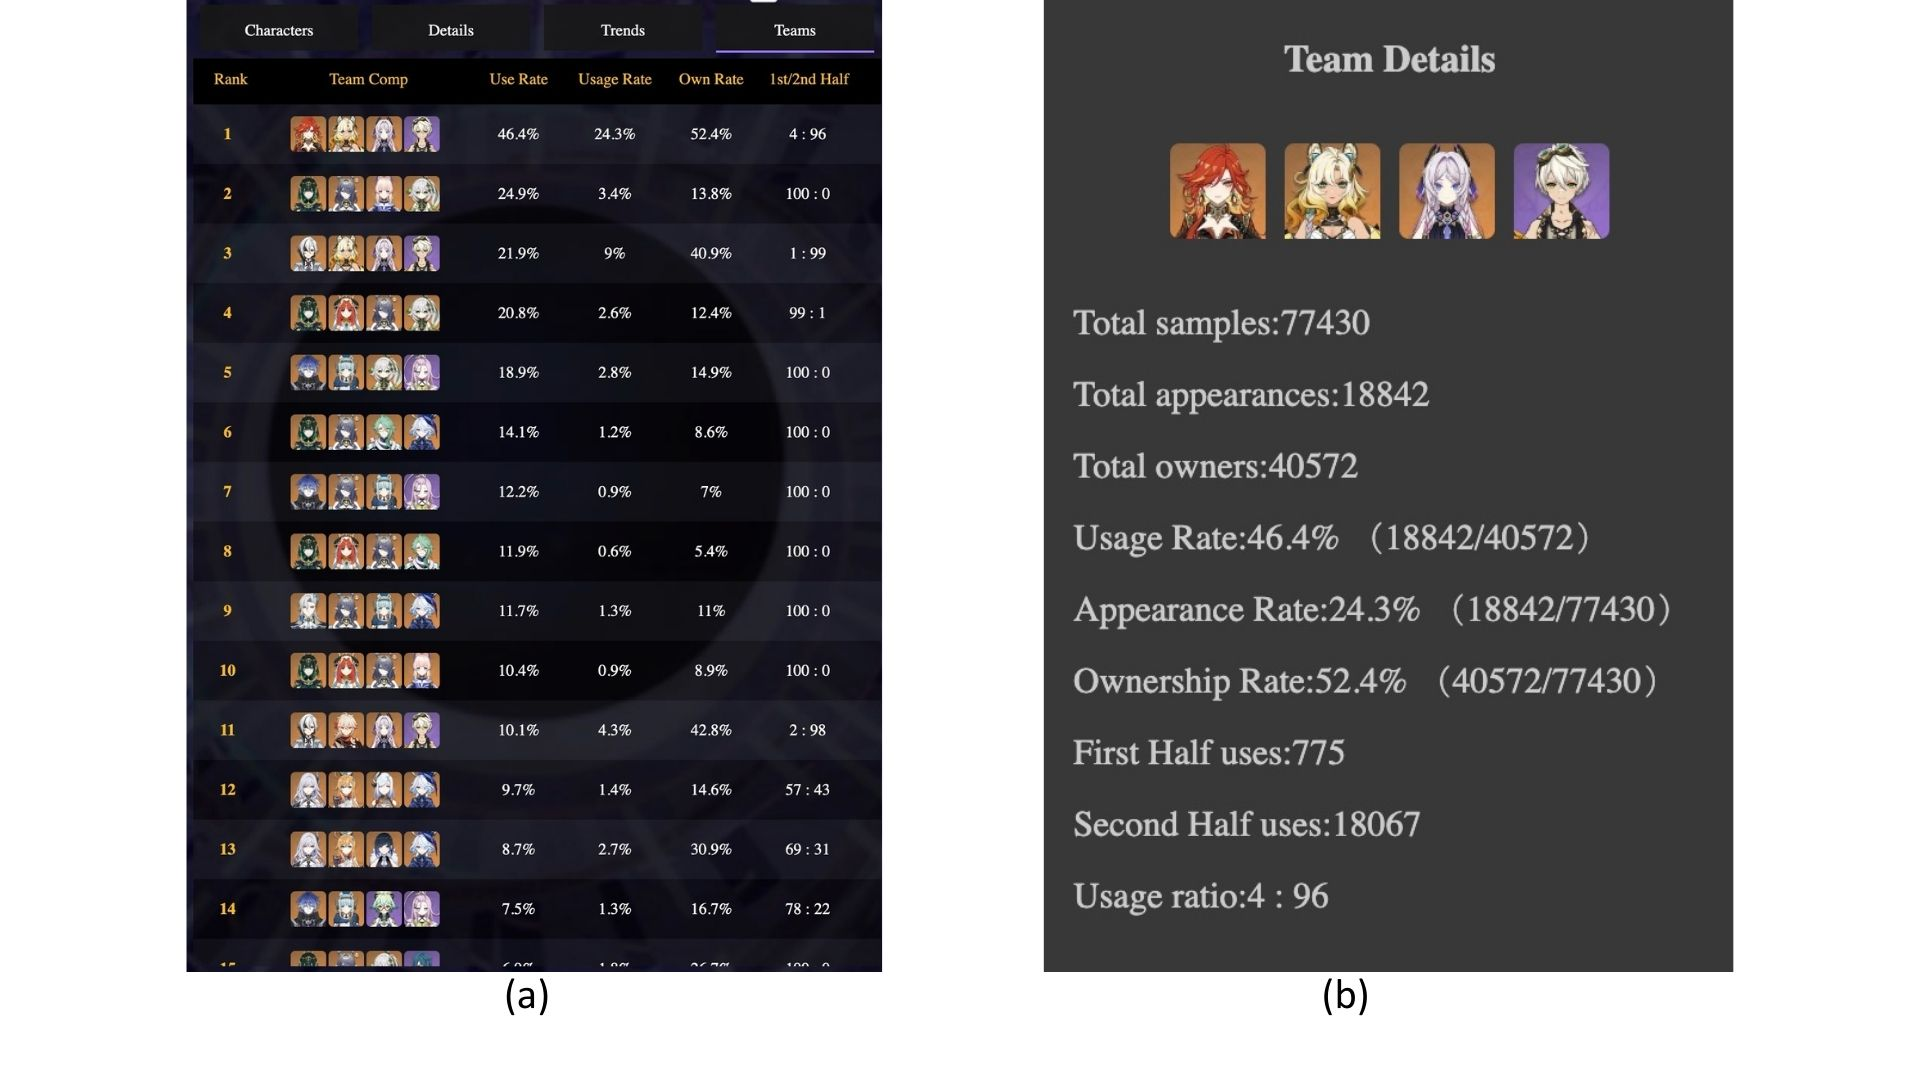

**Figure 4.** YSHelper Team Composition Data Interface with (a) overview of all teams showing monthly usage and ownership and (b) detailed view of a specific team, including total appearances of character pairs


In [4]:
# from 52 to 2
# We start at phase 2 since that is when they started collecting team data
for i in range(52, 1, -1):
    filename = f"data/abyss_graphs/graph_{i}.pickle"

    # If the file already exists, skip it
    if os.path.exists(filename):
        continue

    # Otherwise, create and save the graph
    graph = graph_maker.create_graph(i)
    with open(filename, "wb") as f:
        pickle.dump(graph, f)

    print(f"Created and saved: {filename}")

print(
    "Abyss Team composition data from Sept. 28, 2023 "
    "to Nov. 20, 2025 has been collected."
)

Abyss Team composition data from Sept. 28, 2023 to Nov. 20, 2025 has been collected.


In [5]:
# from 2 to 0
# We start at phase 0 since that is when they started collecting team data
for i in range(1, -1, -1):
    filename = f"data/stygian_graphs/graph_{i}.pickle"

    # If the file already exists, skip it
    if os.path.exists(filename):
        continue

    # Otherwise, create and save the graph
    graph = graph_maker.create_graph(i, mode="stygian")
    with open(filename, "wb") as f:
        pickle.dump(graph, f)

    print(f"Created and saved: {filename}")

print(
    "Stygian Team composition data from June 25, 2025 "
    "to Nov. 20, 2025 has been collected."
)

Stygian Team composition data from June 25, 2025 to Nov. 20, 2025 has been collected.


In collecting character attributes, we web‑scraped data from the Genshin Impact Fandom Wiki to gather the following for each character: name, element, weapon type, region, special property, body type, and role classifications (Fielder‑Type, DPS, Support, Survivability). We also manually recorded the number of voice‑over lines per character based on a Reddit post called [Genshin characters overall voiceline count](https://www.reddit.com/r/Genshin_Impact/comments/1p1yr6g/genshin_characters_overall_voiceline_count/), which was made on November 20, 2025.


In [6]:
df_characteristics = characteristics_maker.get_characteristics()

In [7]:
df_characteristics.head()

,Name,Element,On-Field,Off-Field,DPS,Support,Survivability,Weapon Type,Region,Body Type,Line Count,Star,Use,Own,Pull Number,Free
0,Aino,Hydro,0,1,1,0,0,Claymore,Nodkrai,Loli,430,4,22134,76710,283366,0
1,Albedo,Geo,0,1,1,0,0,Sword,Mondstadt,Boy,1434,5,84,8433,29861,0
2,Alhaitham,Dendro,1,0,1,0,0,Sword,Sumeru,Male,1226,5,2394,26184,56138,0
3,Aloy,Cryo,1,0,1,0,0,Bow,Ranger,Girl,0,5,12,19206,19206,0
4,Amber,Pyro,0,1,1,0,0,Bow,Mondstadt,Girl,779,4,75,77430,250873,0


# V. Explore & Analyze how the Distributions & Relationships of Character Attributes

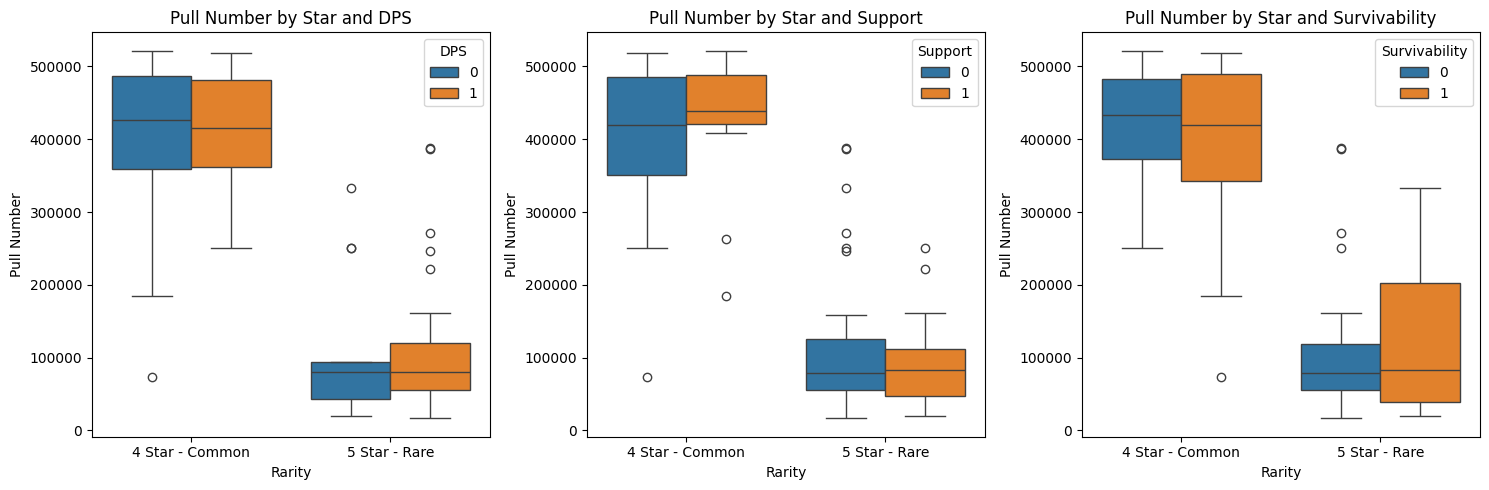

In [8]:
roles = ["DPS", "Support", "Survivability"]
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, role in enumerate(roles):
    sns.boxplot(
        data=df_characteristics,
        x="Star",
        y="Pull Number",
        hue=role,  # optional if you want separate boxes per role
        ax=axs[i],
    )
    axs[i].set_title(f"Pull Number by Star and {role}")
    axs[i].legend(title=role)
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(["4 Star - Common", "5 Star - Rare"])
    axs[i].set_xlabel("Rarity")

plt.tight_layout()
plt.show()

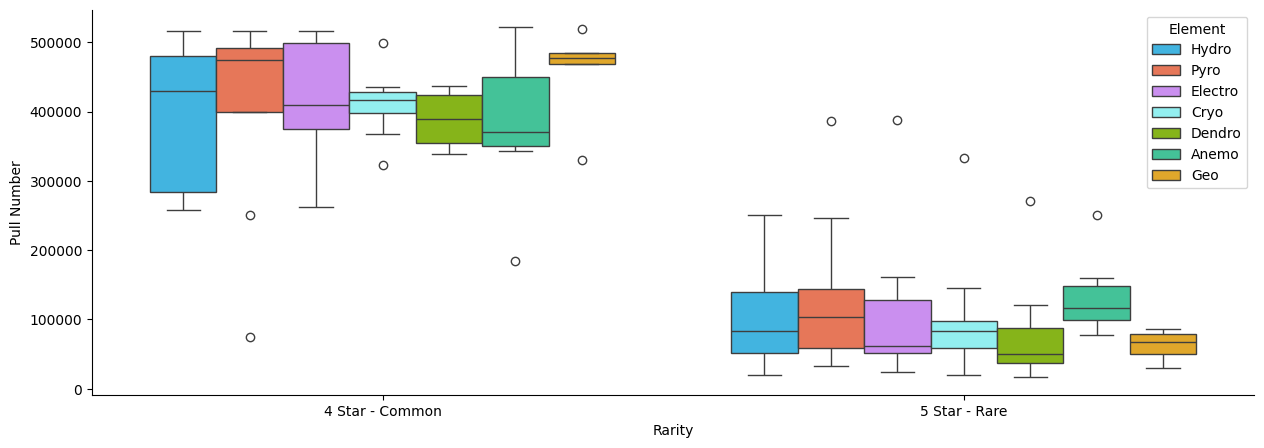

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(15, 5))

element_palette = {
    "Pyro": "#fd6942",  # red/orange
    "Hydro": "#28bffa",  # blue
    "Electro": "#cd7fff",  # yellow
    "Anemo": "#2fd79f",  # light green
    "Geo": "#feb20d",  # brown/gold
    "Cryo": "#84feff",  # icy blue
    "Dendro": "#90ce00",  # green
}

sns.boxplot(
    data=df_characteristics,
    x="Star",
    y="Pull Number",
    hue="Element",
    palette=element_palette,
    ax=axs,
)

axs.set_xticks([0, 1])
axs.set_xticklabels(["4 Star - Common", "5 Star - Rare"])
axs.set_xlabel("Rarity")

axs.spines["top"].set_visible(False)
axs.spines["right"].set_visible(False)

# VI. Predict the Number of Pulls/Wishes  based on In-Game Character Attributes

# Hi Lindsey - JF suggests just doing rlly basic models, like you dont even include yet the character strength (thats for mariel to add)

In [10]:
from sklearn.metrics import make_scorer

# Define SMAPE
def smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    denominator = np.where(denominator == 0, 1, denominator)  # avoid division by zero
    return 100 * np.mean(numerator / denominator)

smape_scorer = make_scorer(smape, greater_is_better=False)  # set False because lower SMAPE is better


In [11]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import LeaveOneOut

# 1. Split features and target
X = df_characteristics.drop(columns=["Name", "Use", "Own", "Pull Number"])
y = df_characteristics["Pull Number"]

# 2. Train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=37
)

# 3. List of categorical columns to encode
categorical_cols = ["Element", "Weapon Type", "Region", "Body Type"]

# 4. Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough",
)

# 5. Random Forest model
rf = RandomForestRegressor(random_state=42)

# 6. Full pipeline: preprocessing + model
pipeline = Pipeline(steps=[("preprocess", preprocessor), ("rf", rf)])

param_grid = {"rf__n_estimators": [50, 100, 200, 300, 500, 1000]}


# 8. K-Fold configuration
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 9. Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring={"MSE": "neg_mean_squared_error", "R2": "r2", "SMAPE": smape_scorer},
    refit="MSE",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

# leave one out
loo = LeaveOneOut()
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=loo,
    scoring={"MSE": "neg_mean_squared_error", "SMAPE": smape_scorer},
    refit="MSE",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)


# Fit only on training data
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV Score (neg MSE):", grid_search.best_score_)

best_model = grid_search.best_estimator_

# 10. Evaluate on the test set
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
smape_te = smape(y_pred, y_test)

print("\nTest RMSE:", rmse)
print("Test MSE:", mse)
print("Test R2:", r2)
print("Test MAPE:", mape)
print("Test SMAPE:", smape_te)

Fitting 84 folds for each of 6 candidates, totalling 504 fits
Best Params: {'rf__n_estimators': 50}
Best CV Score (neg MSE): -8299574636.759233

Test RMSE: 67579.31781723445
Test MSE: 4566964196.642781
Test R2: 0.8569239924863066
Test MAPE: 34.74534213979795
Test SMAPE: 27.57526885477804


# Character Strength Feature Engineering

We calculated a “strength” score for each Genshin Impact character in the Abyss and Stygian end-game modes using network centrality metrics. For each mode, we loaded graphs representing character team usage per patch, computed eigenvector and betweenness centrality, and then scaled them (standardizing eigenvector centrality, and log-transforming + standardizing betweenness centrality). We applied EWMA across patches so that more recent patches had higher influence. Finally, we merged these strength features with our existing character dataset to create a comprehensive feature table.

In [12]:
abyss_data = graph_maker.get_abyss_rank_activity()

abyss_betweenness_df, abyss_eigenvector_df = (
    centrality_maker.compute_centrality_matrices(
        base_dir="data/abyss_graphs",
        output_name_prefix="abyss",
        patch_labels=abyss_data["Patch Label"],
    )
)

stygian_betweenness_df, stygian_eigenvector_df = (
    centrality_maker.compute_centrality_matrices(
        base_dir="data/stygian_graphs",
        output_name_prefix="stygian",
        patch_labels=abyss_data["Patch Label"][[47, 48, 50]],
    )
)

Computed and saved centrality matrices for abyss
Computed and saved centrality matrices for stygian


In [277]:
def centrality_from_csv(csv_path, name, alpha=0.3):
    """
    Read centrality values from CSV and return EWMA-smoothed values.
    
    CSV format:
    - Rows: characters
    - Columns: patches
    - Values: centrality (NaN if not present)
    """
    # Read CSV
    df = pd.read_csv(csv_path, index_col=0)  # first column = character names

    # Fill NaN with 0 (character not present in patch)
    df_filled = df.fillna(0)

    # Compute EWMA across patches (columns)
    df_ewma = df_filled.T.ewm(alpha=alpha).mean().T

    # Take the last column = most recent EWMA per character
    df_final = df_ewma.iloc[:, -1]

    df_final = df_final.reset_index(name=name)

    return df_final.rename(columns={"index":"Name"})  # pd.Series: index = character, value = EWMA-smoothed centrality


In [278]:
abyss_ev = centrality_from_csv('data/abyss_eigenvector.csv', 'Abyss Eigenvector')
abyss_between = centrality_from_csv('data/abyss_betweenness.csv', 'Abyss Betweenness')

stygian_ev = centrality_from_csv('data/stygian_eigenvector.csv', 'Stygian Eigenvector')
stygian_between = centrality_from_csv('data/stygian_betweenness.csv', 'Stygian Betweenness')

meta_df = pd.concat([abyss_ev, abyss_between, stygian_ev, stygian_between], axis=1).drop(columns=['Name'])
meta_df.corr()

,Abyss Eigenvector,Abyss Betweenness,Stygian Eigenvector,Stygian Betweenness
Abyss Eigenvector,1.000000,0.743407,0.973110,0.830658
Abyss Betweenness,0.743407,1.000000,0.671868,0.971852
Stygian Eigenvector,0.973110,0.671868,1.000000,0.773957
Stygian Betweenness,0.830658,0.971852,0.773957,1.000000


In [263]:
# Merge the new strength features with existing character features
df_merged = pd.concat([df_characteristics, meta_df], axis=1)
df_merged

,Name,Element,On-Field,Off-Field,DPS,Support,Survivability,Weapon Type,Region,Body Type,Line Count,Star,Use,Own,Pull Number,Free,Abyss Eigenvector,Abyss Betweenness,Stygian Eigenvector,Stygian Betweenness
0,Aino,Hydro,0,1,1,0,0,Claymore,Nodkrai,Loli,430,4,22134,76710,283366,0,0.027440,6.337192e-02,0.038464,0.063977
1,Albedo,Geo,0,1,1,0,0,Sword,Mondstadt,Boy,1434,5,84,8433,29861,0,0.000455,5.233822e-10,0.000143,0.000000
2,Alhaitham,Dendro,1,0,1,0,0,Sword,Sumeru,Male,1226,5,2394,26184,56138,0,0.024653,3.215914e-03,0.011323,0.000000
3,Aloy,Cryo,1,0,1,0,0,Bow,Ranger,Girl,0,5,12,19206,19206,0,0.000079,0.000000e+00,0.000101,0.000000
4,Amber,Pyro,0,1,1,0,0,Bow,Mondstadt,Girl,779,4,75,77430,250873,0,0.000153,1.440600e-03,0.001531,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Yelan,Hydro,0,1,1,0,0,Bow,Liyue,Lady,954,5,16695,54702,118758,0,0.104929,1.576984e-02,0.164713,0.032943
101,Yoimiya,Pyro,1,0,1,0,0,Bow,Inazuma,Girl,1165,5,1662,23445,64356,0,0.006728,1.039608e-03,0.002821,0.000000
102,Yumemizuki Mizuki,Anemo,1,0,1,0,1,Catalyst,Inazuma,Girl,620,5,42,58308,145303,1,0.000772,0.000000e+00,0.000458,0.000000
103,Yun Jin,Geo,0,1,0,1,0,Polearm,Liyue,Girl,718,4,117,73437,468601,0,0.000432,1.998295e-10,0.000399,0.000000


In [264]:
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # To avoid division by zero
    denominator = np.where(denominator == 0, 1, denominator)
    return 100 * np.mean(numerator / denominator)


In [279]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPRegressor

# 1. Split features and target
X = df_merged.drop(columns=["Name", "Use", "Own", "Pull Number"])
#X = X.loc[is_rare]
y = df_merged.loc[:, "Pull Number"]

# 2. Train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=37
)

# 3. Categorical and numeric columns
categorical_cols = ["Element", "Weapon Type", "Body Type"]
standardized_cols = ['Line Count']
binary_features = ['Abyss Betweenness', 'Abyss Eigenvector', 'On-Field', 'DPS', 'Support', 'Survivability', 'Star', 'Free']
# 4. Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), standardized_cols),
        ('bin', 'passthrough', binary_features)
    ]
)

# 5. Neural Network model
mlp = MLPRegressor(
    random_state=42,
    max_iter=5000,
    learning_rate_init=0.001,
    solver="adam",
    early_stopping=True,
    n_iter_no_change=50,
    validation_fraction=0.2,
)

# 6. Full pipeline
pipeline = Pipeline(steps=[("preprocess", preprocessor), ("mlp", mlp)])

# 7. Hyperparameter grid
param_grid = {
    "mlp__hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [0.0001, 0.001],  # L2 regularization
    "mlp__learning_rate": ["constant", "adaptive"],
}

# 8. K-Fold configuration
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 9. Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring={"MSE": "neg_mean_squared_error", "R2": "r2", "SMAPE": smape_scorer},
    refit="MSE",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

loo = LeaveOneOut()
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=loo,
    scoring={"MSE": "neg_mean_squared_error", "SMAPE": smape_scorer},
    refit="MSE",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)


# Fit on training data
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV Score (neg MSE):", grid_search.best_score_)

best_model = grid_search.best_estimator_

# 10. Evaluate on the test set
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
smape_te = smape(y_test, y_pred)
print("\nTest RMSE:", rmse)
print("Test MSE:", mse)
print("Test R2:", r2)
print("Test MAPE:", mape)
print("Test SMAPE:", smape_te)


Fitting 84 folds for each of 24 candidates, totalling 2016 fits
Best Params: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (100, 50), 'mlp__learning_rate': 'constant'}
Best CV Score (neg MSE): -87601403843.14154

Test RMSE: 308393.3202950185
Test MSE: 95106440002.58586
Test R2: -1.9795393917065476
Test MAPE: 99.98787116403945
Test SMAPE: 199.95149569143064


In [280]:
# 5. Random Forest model
rf = RandomForestRegressor(random_state=42)

# 6. Full pipeline: preprocessing + model
pipeline = Pipeline(steps=[("preprocess", preprocessor), ("rf", rf)])

param_grid = {"rf__n_estimators": [50, 100, 200, 300, 500, 1000]}


# 8. K-Fold configuration
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 9. Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring={"MSE": "neg_mean_squared_error", "R2": "r2", "SMAPE": smape_scorer},
    refit="MSE",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

loo = LeaveOneOut()
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=loo,
    scoring={"MSE": "neg_mean_squared_error", "SMAPE": smape_scorer},
    refit="MSE",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)


# Fit only on training data
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV Score (neg MSE):", grid_search.best_score_)

best_model = grid_search.best_estimator_

# 10. Evaluate on the test set
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
smape_te = smape(y_test, y_pred)

print("\nTest RMSE:", rmse)
print("Test MSE:", mse)
print("Test R2:", r2)
print("Test MAPE:", mape)
print("Test SMAPE:", smape_te)


Fitting 84 folds for each of 6 candidates, totalling 504 fits
Best Params: {'rf__n_estimators': 300}
Best CV Score (neg MSE): -7250381332.234666

Test RMSE: 71891.2305711818
Test MSE: 5168349033.038825
Test R2: 0.8380835248001194
Test MAPE: 29.53258922492496
Test SMAPE: 25.8209029097299


In [269]:
pd.DataFrame(grid_search.cv_results_).columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_mlp__activation', 'param_mlp__alpha',
       'param_mlp__hidden_layer_sizes', 'param_mlp__learning_rate', 'params',
       'split0_test_MSE', 'split1_test_MSE', 'split2_test_MSE',
       'split3_test_MSE', 'split4_test_MSE', 'mean_test_MSE', 'std_test_MSE',
       'rank_test_MSE', 'split0_train_MSE', 'split1_train_MSE',
       'split2_train_MSE', 'split3_train_MSE', 'split4_train_MSE',
       'mean_train_MSE', 'std_train_MSE', 'split0_test_R2', 'split1_test_R2',
       'split2_test_R2', 'split3_test_R2', 'split4_test_R2', 'mean_test_R2',
       'std_test_R2', 'rank_test_R2', 'split0_train_R2', 'split1_train_R2',
       'split2_train_R2', 'split3_train_R2', 'split4_train_R2',
       'mean_train_R2', 'std_train_R2', 'split0_test_SMAPE',
       'split1_test_SMAPE', 'split2_test_SMAPE', 'split3_test_SMAPE',
       'split4_test_SMAPE', 'mean_test_SMAPE', 'std_test_SMAPE',
       'rank_test_SMAPE', 'sp

In [272]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_mlp__activation,param_mlp__alpha,param_mlp__hidden_layer_sizes,param_mlp__learning_rate,params,split0_test_MSE,...,mean_test_SMAPE,std_test_SMAPE,rank_test_SMAPE,split0_train_SMAPE,split1_train_SMAPE,split2_train_SMAPE,split3_train_SMAPE,split4_train_SMAPE,mean_train_SMAPE,std_train_SMAPE
0,0.034157,0.005309,0.008471,0.002341,relu,0.0001,"(50,)",constant,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",-6.281312e+10,...,-199.978433,0.005375,19,-199.979113,-199.977107,-199.979843,-199.976674,-199.979712,-199.978490,0.001336
1,0.034487,0.008292,0.003953,0.001563,relu,0.0001,"(50,)",adaptive,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",-6.281312e+10,...,-199.978433,0.005375,19,-199.979113,-199.977107,-199.979843,-199.976674,-199.979712,-199.978490,0.001336
2,0.029132,0.005941,0.003229,0.001390,relu,0.0001,"(100,)",constant,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",-6.281287e+10,...,-199.976590,0.005548,15,-199.977136,-199.975728,-199.977935,-199.974681,-199.978011,-199.976698,0.001300
3,0.032217,0.010787,0.005451,0.006601,relu,0.0001,"(100,)",adaptive,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",-6.281287e+10,...,-199.976590,0.005548,15,-199.977136,-199.975728,-199.977935,-199.974681,-199.978011,-199.976698,0.001300
4,0.047966,0.014438,0.002801,0.000777,relu,0.0001,"(100, 50)",constant,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",-6.281041e+10,...,-199.946958,0.011835,3,-199.948164,-199.945242,-199.948939,-199.942537,-199.950918,-199.947160,0.002944
5,0.053303,0.010681,0.003646,0.001433,relu,0.0001,"(100, 50)",adaptive,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",-6.281041e+10,...,-199.946958,0.011835,3,-199.948164,-199.945242,-199.948939,-199.942537,-199.950918,-199.947160,0.002944
6,0.034577,0.011745,0.006751,0.003930,relu,0.0010,"(50,)",constant,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",-6.281312e+10,...,-199.978424,0.005376,17,-199.979107,-199.977100,-199.979834,-199.976668,-199.979709,-199.978484,0.001336
7,0.026741,0.012660,0.003801,0.001621,relu,0.0010,"(50,)",adaptive,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",-6.281312e+10,...,-199.978424,0.005376,17,-199.979107,-199.977100,-199.979834,-199.976668,-199.979709,-199.978484,0.001336
8,0.025560,0.013866,0.003378,0.001610,relu,0.0010,"(100,)",constant,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",-6.281286e+10,...,-199.976566,0.005558,13,-199.977114,-199.975704,-199.977922,-199.974669,-199.977976,-199.976677,0.001297
9,0.029963,0.009196,0.004487,0.004287,relu,0.0010,"(100,)",adaptive,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",-6.281286e+10,...,-199.976566,0.005558,13,-199.977114,-199.975704,-199.977922,-199.974669,-199.977976,-199.976677,0.001297


In [ ]:
# Merge the new strength features with existing character features
df_merged = pd.concat([df_characteristics, meta_df], axis=1)
df_merged

,Name,Element,On-Field,Off-Field,DPS,Support,Survivability,Weapon Type,Region,Body Type,Line Count,Star,Use,Own,Pull Number,Free,Abyss Eigenvector,Abyss Betweenness,Stygian Eigenvector,Stygian Betweenness
0,Aino,Hydro,0,1,1,0,0,Claymore,Nodkrai,Loli,430,4,22134,76710,283366,0,0.027440,6.337192e-02,0.038464,0.063977
1,Albedo,Geo,0,1,1,0,0,Sword,Mondstadt,Boy,1434,5,84,8433,29861,0,0.000455,5.233822e-10,0.000143,0.000000
2,Alhaitham,Dendro,1,0,1,0,0,Sword,Sumeru,Male,1226,5,2394,26184,56138,0,0.024653,3.215914e-03,0.011323,0.000000
3,Aloy,Cryo,1,0,1,0,0,Bow,Ranger,Girl,0,5,12,19206,19206,0,0.000079,0.000000e+00,0.000101,0.000000
4,Amber,Pyro,0,1,1,0,0,Bow,Mondstadt,Girl,779,4,75,77430,250873,0,0.000153,1.440600e-03,0.001531,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Yelan,Hydro,0,1,1,0,0,Bow,Liyue,Lady,954,5,16695,54702,118758,0,0.104929,1.576984e-02,0.164713,0.032943
101,Yoimiya,Pyro,1,0,1,0,0,Bow,Inazuma,Girl,1165,5,1662,23445,64356,0,0.006728,1.039608e-03,0.002821,0.000000
102,Yumemizuki Mizuki,Anemo,1,0,1,0,1,Catalyst,Inazuma,Girl,620,5,42,58308,145303,1,0.000772,0.000000e+00,0.000458,0.000000
103,Yun Jin,Geo,0,1,0,1,0,Polearm,Liyue,Girl,718,4,117,73437,468601,0,0.000432,1.998295e-10,0.000399,0.000000


<Axes: >

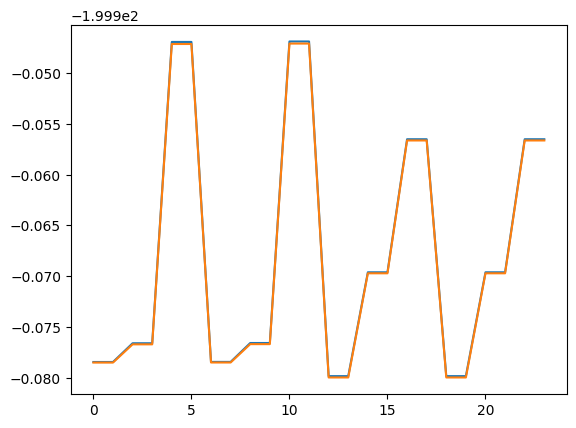

In [271]:
pd.DataFrame(grid_search.cv_results_)['mean_test_SMAPE'].plot()
pd.DataFrame(grid_search.cv_results_)['mean_train_SMAPE'].plot()

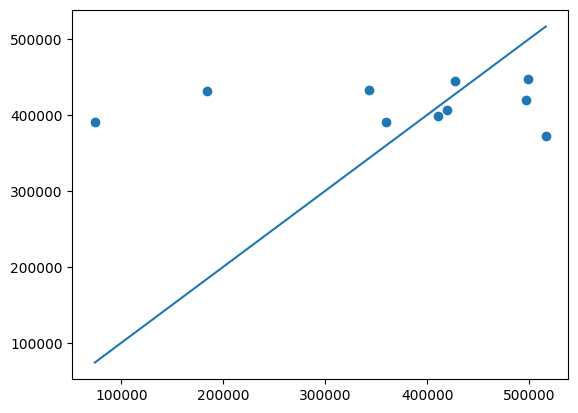

In [209]:
plt.scatter(y_test, y_pred)
min, max = y_test.min(), y_test.max()
plt.plot(np.linspace(min, max), np.linspace(min, max))

# VII. Limitations and Recommendations 

**Limitations**

**Business Limitations**  
- **Biased data**: Our data comes from voluntary reports by players who play advanced content. This does not represent all players since many casual players may wish for characters but are not included in our dataset.  
- **Pulls as a demand proxy**: We estimate demand for characters based on how many times players try to get them. However, we  do not know how much money was actually spent on pulls, which would be more valuable for financial insights. It may be possible that majority of the wishes was given for free by the game. 

**Technical Limitations**  
- **Static prediction**: Our model predicts character ownership only for the latest game version (November 2025). We did not account for changes over time or trends due to the lack of time.  
- **Limited game mode coverage**: We only analyzed two end-game modes of Spiral Abyss and Stygian Onslaught. We could not include Imaginarium Theatre, which is another game mode. In Imaginarium Theatre, players must use their characters creatively across 10 levels, instead of just focusing on doing the most damage in 3 levels. Players have to plan carefully how they use each character so they can save them for harder levels later. This mode would give more interesting insights into how players build their teams.

---

**Recommendations**

**Business Recommendations**  
- **Broaden financial insight**: If possible, incorporate actual spending data to better understand which characters generate revenue and which are just pulled frequently by free-to-play users.  
- **Expand to other games**: Apply this analysis to other games with similar “wish” mechanics such as Wuthering Waves to compare player behavior and demand across games.  

**Technical Recommendations**  
- **Include other game modes**: Extend the model to include Imaginarium Theatre.  
- **Time series analysis**: Instead of predicting ownership at a single point in time, track data across multiple versions to understand trends and predict future demand more accurately.


# VIII. Conclusion 